# **trends  among the richest people in the world**

 let's see if we can use Kernel PCA to help us better visualize if any trends exist among the richest people in the world. "The World's Billionaires" is an annual ranking documenting the net worth of the wealthiest billionaires in the world, compiled and published in March, annually, by the American business magazine - Forbes. For this lab, we obtained the dataset from <a href="https://www.kaggle.com/datasets/jjdaguirre/forbes-billionaires-2022"> here</a>.

The features available from the dataset are:

- Rank
- Name
- Net Worth - their net worth in billions USD
- Age
- Country
- Source - their source of income
- Industry - sector/industry/market segment in which each billionaire has made their fortune


In [3]:
# Surpress warnings from using older version of sklearn:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import numpy as np
import pandas as pd
from itertools import accumulate

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA,KernelPCA
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


warnings.filterwarnings('ignore')

sns.set_context('notebook')
sns.set_style('white')
print("Libraries imported successfully!")


Libraries imported successfully!


In [4]:
def plot_proj(A,v,y,name=None):

    plt.scatter(A[:,0],A[:,1],label='data',c=y,cmap='viridis')
    
    #plt.plot(np.linspace(A[:,0].min(),A[:,0].max()),np.linspace(A[:,1].min(),A[:,1].max())*(v[1]/v[0]),color='black',linestyle='--',linewidth=1.5,label=name)   
    plt.plot(np.linspace(-1,1),np.linspace(-1,1)*(v[1]/v[0]),color='black',linestyle='--',linewidth=1.5,label=name)  
    # Run through all the data

    for i in range(len(A[:,0])-1):
        #data point 
        w=A[i,:]

        # projection
        cv = (np.dot( A[i,:],v))/np.dot(v,np.transpose(v))*v

        # line between data point and projection
        plt.plot([A[i,0],cv[0]],[A[i,1],cv[1]],'r--',linewidth=1.5)
    plt.plot([A[-1,0],cv[0]],[A[-1,1],cv[1]],'r--',linewidth=1.5,label='projections' )
    plt.legend()
    plt.show()

# Visual Example: Transform a Dataset Before Applying  PCA
Let's look at an example that will visually demonstrate kernel PCA in action. Consider the ```make_circles``` toy dataset. The dataset contains a large ring of one class, enclosing a smaller ring of another class in 2 dimensions.  


In [5]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# Create the toy dataset
X, y = make_circles(n_samples=1000, factor=0.01, noise=0.05, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

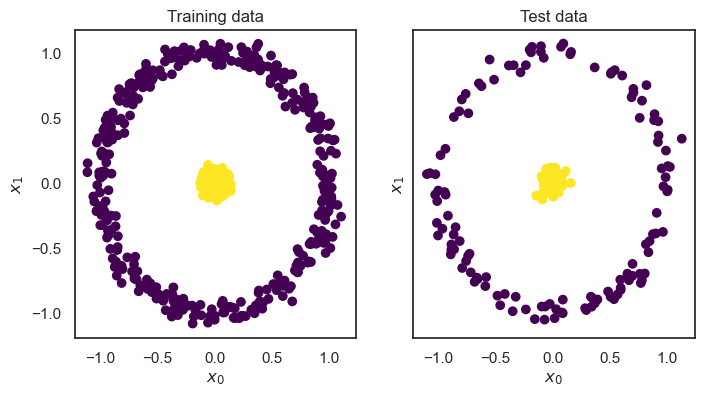

In [6]:
# Visualize the data
_, (train_ax, test_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(8, 4))

train_ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,cmap='viridis')
train_ax.set_xlabel("$x_{0}$")
train_ax.set_ylabel("$x_{1}$")
train_ax.set_title("Training data")

test_ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test,cmap='viridis')
test_ax.set_xlabel("$x_{0}$")
test_ax.set_ylabel("$x_{1}$")
test_ax.set_title("Test data")
plt.show()

### Apply PCA
There are several issues with the dataset above, the first being samples from each class cannot be linearly separated: no plane can split the samples of the inner ring from the outer ring. Let's see what happens when we perform PCA and evaluate the projection or score.


In [7]:
from sklearn.decomposition import PCA

# Fit on a PCA object
pca = PCA(n_components=2)

score_pca = pca.fit(X_train).transform(X_test)
pca

PCA(n_components=2)

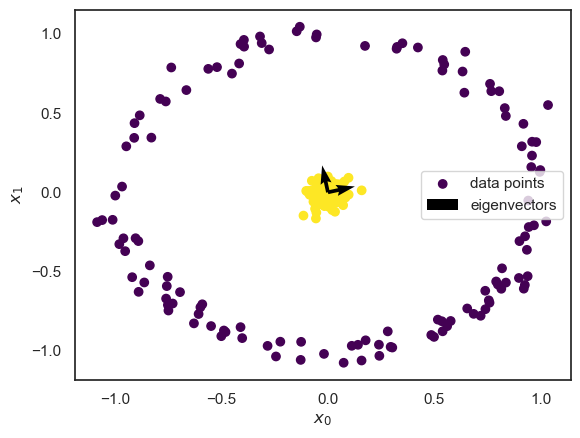

In [8]:
#plot the 2 principal components and the data points
plt.scatter(score_pca[:, 0], score_pca[:, 1], c=y_test,label="data points", cmap='viridis')
plt.quiver([0,0],[0,0], pca.components_[0,:], pca.components_[1,:], label="eigenvectors")
plt.xlabel("$x_{0}$")
plt.ylabel("$x_{1}$")
plt.legend(loc='center right')
plt.show()

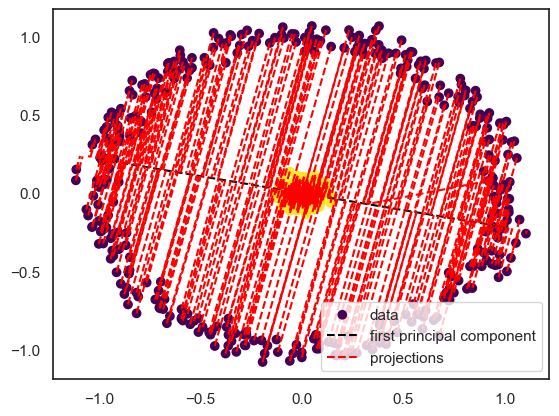

In [9]:
plot_proj(X_train,pca.components_[0,:],y_train,"first principal component")

The following red lines show the direction of projection onto the first principal component (the black dotted line) for each data point.


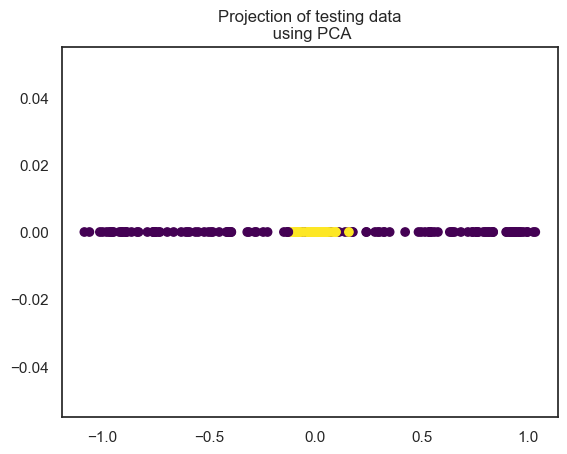

In [10]:
#plot out the actual points of projection onto the first principal component
plt.scatter(score_pca [:,0],np.zeros(score_pca[:,0].shape[0]),c=y_test,cmap='viridis')
plt.title("Projection of testing data\n using PCA")
plt.show()

we see the data looks the same, or isotropic, meaning that it has the same value when measured in a different coordinate system. This is because the data is symmetric and the variance is equal on each side. As a result, PCA will not help us classify the data.

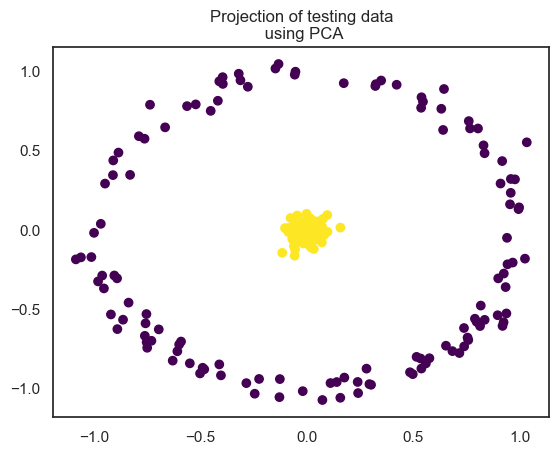

In [11]:
plt.scatter(score_pca[:, 0], score_pca[:, 1], c=y_test,cmap='viridis')
plt.title("Projection of testing data\n using PCA")
plt.show()


Building a Logistic Regression model on the training set, we can see that the accuracy score is around 50%, suggesting that the model is arbitrarily worse. Hence, we can see that it'd be unsuitable to project the data onto a low-dimensional linear subspace.


In [12]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression().fit(X_train, y_train)
print(str.format("Test set  mean accuracy score for for PCA: {}", lr.score(X_test, y_test)))

Test set  mean accuracy score for for PCA: 0.496


### Transform a Dataset to a Higher Dimension and then Apply PCA
apply the following polynomial transformation to the data:

$\mathbf{\phi}(\mathbf{x})=[x_{1},x_{2},x_{1}^2+x_{2}^2]$ where $\mathbf{x}=[x_{1},x_{2}]$


In [13]:
PHI_train=np.concatenate((X_train, (X_train**2).sum(axis=1).reshape(-1,1)),axis=1)
PHI_test=np.concatenate((X_test, (X_test**2).sum(axis=1).reshape(-1,1)),axis=1)

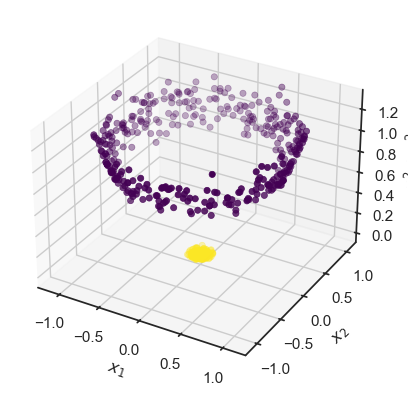

In [14]:
# Plot in 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(PHI_train[:,0], PHI_train[:,1],  PHI_train[:,2], c=y_train, cmap='viridis', linewidth=0.5);
ax.set_xlabel('$x_{1}$')
ax.set_ylabel('$x_{2}$')
ax.set_zlabel('$x_{1}^2+x_{2}^2$')
plt.show()

In [15]:
#we now perform PCA on the transformed data , keeping the threee first principal components
pca = PCA(n_components=3)
score_polly = pca.fit(PHI_train).transform(PHI_test)

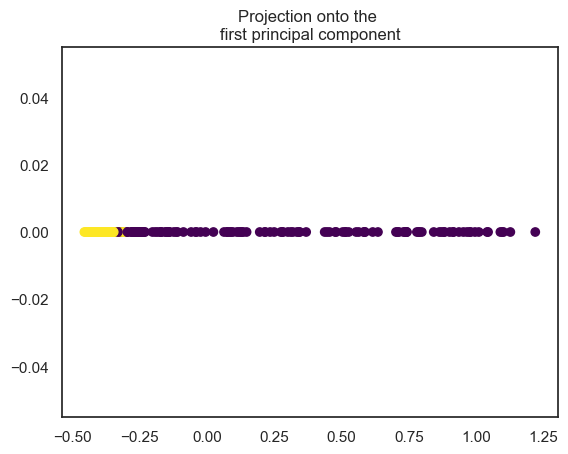

In [16]:
#plot the data points s projection onto the first PC/score
plt.scatter(score_polly[:,0],np.zeros(score_polly[:,1].shape[0]),c=y_test,cmap='viridis')
plt.title("Projection onto the \nfirst principal component")
plt.show()

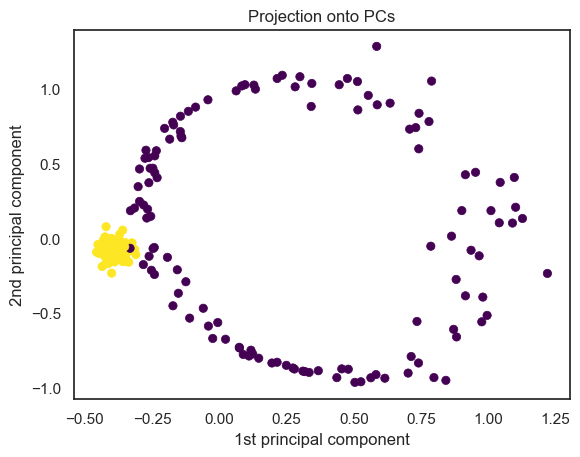

In [17]:
plt.scatter(score_polly[:,0], score_polly[:,1],c=y_test, cmap='viridis', linewidth=0.5);
plt.xlabel("1st principal component")
plt.ylabel("2nd principal component")
plt.title("Projection onto PCs")
plt.show()

In [18]:
#build a logistic regression model on the training data
lr= LogisticRegression().fit(PHI_train, y_train)
print(str.format("Test set  mean accuracy score for for Kernal PCA: {}", lr.score(PHI_test, y_test)))

Test set  mean accuracy score for for Kernal PCA: 1.0


the accuracy is much better

# **Apply kernel PCA**

In [19]:
kernel_pca = KernelPCA( kernel="rbf", gamma=10, fit_inverse_transform=True, alpha=0.1)
kernel_pca.fit(X_train)
score_kernel_pca = kernel_pca.transform(X_test)

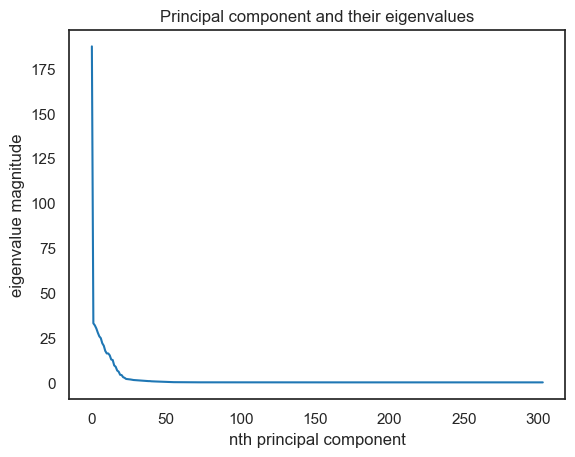

In [20]:
#to show how much variance is explained by each PC 
plt.plot(kernel_pca.eigenvalues_)

plt.title("Principal component and their eigenvalues")
plt.xlabel("nth principal component")
plt.ylabel("eigenvalue magnitude")
plt.show()

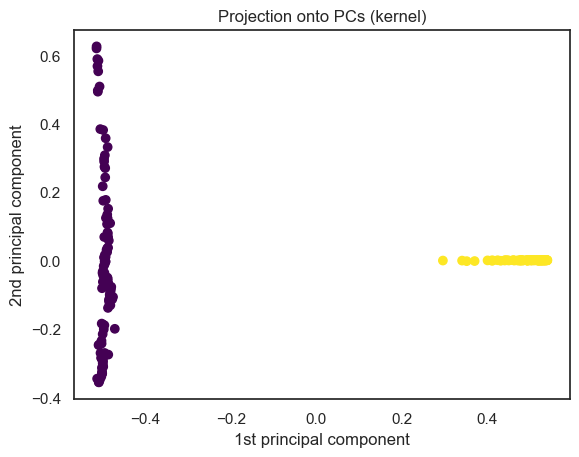

In [21]:
plt.scatter(score_kernel_pca[:,0],score_kernel_pca[:,1] ,c=y_test,cmap='viridis')
plt.title("Projection onto PCs (kernel)")
plt.xlabel("1st principal component")
plt.ylabel("2nd principal component")
plt.show()

by plotting the data points' projection onto the first two principal components, we can see that the data is linearly separable, demonstrating that kernel PCA performs better than our polynomial approximation

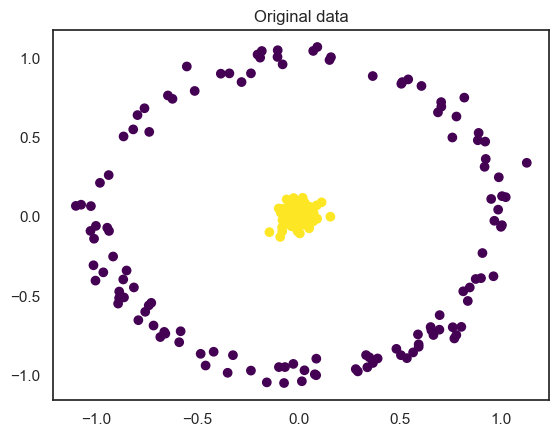

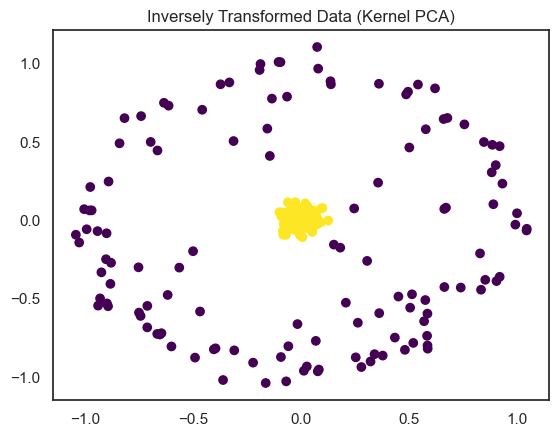

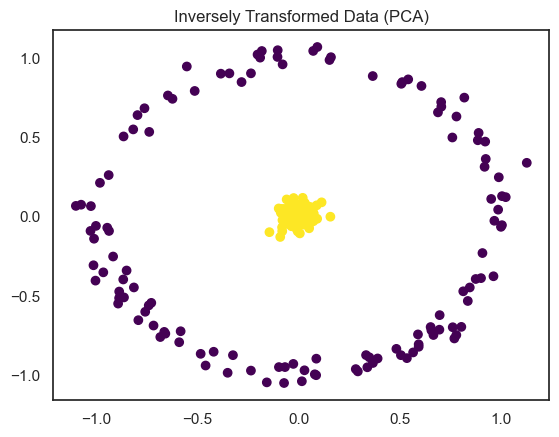

In [22]:
X_hat_kpca = kernel_pca.inverse_transform(kernel_pca.transform(X_test))

pca = PCA(n_components=2)
pca.fit(X_train)
X_hat_pca = pca.inverse_transform(pca.transform(X_test))

plt.scatter(X_test[:,0],X_test[:,1] ,c=y_test,cmap='viridis')
plt.title("Original data")
plt.show()

plt.scatter(X_hat_kpca[:,0],X_hat_kpca[:,1] ,c=y_test,cmap='viridis')
plt.title("Inversely Transformed Data (Kernel PCA)")
plt.show()

plt.scatter(X_hat_pca[:,0],X_hat_pca[:,1] ,c=y_test,cmap='viridis')
plt.title("Inversely Transformed Data (PCA)")
plt.show()

In PCA, the reconstruction was exactly the same as the original component, if ```n_components``` is equal to the dimension of the original features. On the other hand, Kernel PCA does not actually span $\phi(\mathbf{x})$ but instead spans a subspace. Therefore, the inverse transformation will not always reconstruct the data, like in PCA. We can verify this by comparing the inverse transformation of Kernel PCA and PCA. 
 


In [23]:
#calculate the mean squared error between the original data and the inversely transformed data
print("Mean squared error for Kernel PCA is:",((X_test-X_hat_kpca)**2).mean())
print("Mean squared error for PCA is:",((X_test-X_hat_pca)**2).mean())

Mean squared error for Kernel PCA is: 0.01127523172787701
Mean squared error for PCA is: 2.8602080584038387e-33
